# Estra Pistoia Playout Opponent Probability Model

This notebook estimates whether Estra Pistoia are more likely to face **Ruvo di Puglia** or **Cento** in the Serie A2 playouts.

The approach is intentionally transparent:

1. Load real team box score data from CSV.
2. Exclude Bergamo games, because Bergamo withdrew and those games were annulled.
3. Estimate team strength using offensive rating, defensive rating and recent form.
4. Convert the three decisive final-round games into win probabilities.
5. Apply the official scenario logic.
6. Run a Monte Carlo simulation.

This is not a betting model. It is a reproducible basketball analytics exercise for scenario analysis.


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INPUT_CSV = "serie_a2_team_boxscores.csv"

BERGAMO_TEAM = "Gruppo Mascio Bergamo"
EXCLUDE_BERGAMO_GAMES = True

DECISIVE_GAMES = {
    "Cento vs Pistoia": {"home": "Sella Cento", "away": "Estra Pistoia"},
    "Brindisi vs Ruvo": {"home": "Valtur Brindisi", "away": "Crifo Wines Ruvo di Puglia"},
    "Avellino vs Roseto": {"home": "Avellino Basket", "away": "Liofilchem Roseto"},
}

HOME_ADVANTAGE_POINTS = 2.5
RECENT_N_GAMES = 8
RECENT_WEIGHT = 0.35
MARGIN_SCALE = 11.0
N_SIM = 100_000
RANDOM_SEED = 42


## 1. Load the dataset

In [12]:
df = pd.read_csv(INPUT_CSV)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df.shape


(357, 66)

## 2. Exclude Bergamo games

Bergamo withdrew from the league and their games were annulled for official standings purposes.  
For this reason, this model excludes games involving Bergamo.


In [ ]:
model_df = df.copy()

if EXCLUDE_BERGAMO_GAMES:
    model_df = model_df[
        (model_df["home_team"] != BERGAMO_TEAM) &
        (model_df["away_team"] != BERGAMO_TEAM)
    ].copy()

df.head()


(357, 66)


,game_id,date,time,game_folder,game_url,home_team,away_team,home_pts,away_pts,home_win,...,away_fgm,away_fga,home_possessions_proxy,away_possessions_proxy,home_off_rating_proxy,away_off_rating_proxy,away_def_rating_proxy,home_def_rating_proxy,schedule_home_team,schedule_away_team
0,837673,2025-09-20,6:30 PM,sep-20-2025_837673_juvi-cremona_vs_forli,https://www.proballers.com/basketball/game/837...,Ferraroni Juvi Cremona,Unieuro Forli,78,70,1,...,24,58,70.4,71.9,110.795455,97.357441,110.795455,97.357441,Juvi Cremona,Forli
1,837681,2025-09-20,6:30 PM,sep-20-2025_837681_wegreenit-urania-milano_vs_...,https://www.proballers.com/basketball/game/837...,Wegreenit Urania Milano,Dole Basket Rimini,73,82,0,...,30,68,69.6,73.6,104.885057,111.413043,104.885057,111.413043,Wegreenit Urania Milano,Rimini
2,837672,2025-09-21,4:00 PM,sep-21-2025_837672_ruvo-di-puglia_vs_brindisi,https://www.proballers.com/basketball/game/837...,Crifo Wines Ruvo di Puglia,Valtur Brindisi,58,94,0,...,36,68,72.9,74.7,79.561043,125.836680,79.561043,125.836680,Ruvo di Puglia,Brindisi
3,837674,2025-09-21,4:00 PM,sep-21-2025_837674_scafati_vs_mestre,https://www.proballers.com/basketball/game/837...,Givova Scafati,Gemini Mestre,76,61,1,...,25,63,73.8,76.5,102.981030,79.738562,102.981030,79.738562,Scafati,Mestre
4,837677,2025-09-21,5:30 PM,sep-21-2025_837677_liofilchem-roseto_vs_fortit...,https://www.proballers.com/basketball/game/837...,Liofilchem Roseto,Fortitudo Bologna,86,82,1,...,24,59,69.6,72.4,123.563218,113.259669,123.563218,113.259669,Liofilchem Roseto,Fortitudo Bologna


## 3. Convert home/away box scores into one row per team game

In [4]:
rows = []

for _, r in model_df.iterrows():
    rows.append({
        "game_id": r["game_id"],
        "date": r["date"],
        "team": r["home_team"],
        "opponent": r["away_team"],
        "is_home": 1,
        "pts_for": r["home_pts"],
        "pts_against": r["away_pts"],
        "win": r["home_win"],
        "poss": r["home_possessions_proxy"],
        "off_rating": r["home_off_rating_proxy"],
        "def_rating": r["home_def_rating_proxy"],
    })

    rows.append({
        "game_id": r["game_id"],
        "date": r["date"],
        "team": r["away_team"],
        "opponent": r["home_team"],
        "is_home": 0,
        "pts_for": r["away_pts"],
        "pts_against": r["home_pts"],
        "win": r["away_win"],
        "poss": r["away_possessions_proxy"],
        "off_rating": r["away_off_rating_proxy"],
        "def_rating": r["away_def_rating_proxy"],
    })

long_df = pd.DataFrame(rows).sort_values(["team", "date"])
long_df.head()


,game_id,date,team,opponent,is_home,pts_for,pts_against,win,poss,off_rating,def_rating
17,837679,2025-09-24,Avellino Basket,Real Sebastiani Rieti,0,72,60,1,73.9,97.428958,80.000000
26,837686,2025-09-28,Avellino Basket,Wegreenit Urania Milano,1,74,75,0,65.7,112.633181,116.640747
53,837700,2025-10-05,Avellino Basket,Tezenis Verona,0,92,98,0,71.7,128.312413,136.490251
57,837705,2025-10-08,Avellino Basket,Ferraroni Juvi Cremona,0,78,68,1,71.8,108.635097,93.406593
80,837716,2025-10-12,Avellino Basket,Valtur Brindisi,1,59,82,0,72.4,81.491713,122.754491


## 4. Build team strength ratings

The model blends:

- full-season offensive and defensive rating;
- last 8 games offensive and defensive rating.

Recent form is useful here because Pistoia's roster changed significantly during the season.


In [5]:
def weighted_avg(values, weights):
    values = pd.Series(values)
    weights = pd.Series(weights)
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])


team_rows = []

for team, g in long_df.groupby("team"):
    g = g.sort_values("date")
    recent = g.tail(RECENT_N_GAMES)

    season_off = weighted_avg(g["off_rating"], g["poss"])
    season_def = weighted_avg(g["def_rating"], g["poss"])
    recent_off = weighted_avg(recent["off_rating"], recent["poss"])
    recent_def = weighted_avg(recent["def_rating"], recent["poss"])

    blended_off = (1 - RECENT_WEIGHT) * season_off + RECENT_WEIGHT * recent_off
    blended_def = (1 - RECENT_WEIGHT) * season_def + RECENT_WEIGHT * recent_def

    team_rows.append({
        "team": team,
        "games": len(g),
        "wins": int(g["win"].sum()),
        "losses": int(len(g) - g["win"].sum()),
        "win_pct": g["win"].mean(),
        "season_off_rating": season_off,
        "season_def_rating": season_def,
        "season_net_rating": season_off - season_def,
        f"last_{RECENT_N_GAMES}_off_rating": recent_off,
        f"last_{RECENT_N_GAMES}_def_rating": recent_def,
        f"last_{RECENT_N_GAMES}_net_rating": recent_off - recent_def,
        "blended_off_rating": blended_off,
        "blended_def_rating": blended_def,
        "blended_net_rating": blended_off - blended_def,
    })

team_stats = pd.DataFrame(team_rows).sort_values("blended_net_rating", ascending=False)
team_stats


,team,games,wins,losses,win_pct,season_off_rating,season_def_rating,season_net_rating,last_8_off_rating,last_8_def_rating,last_8_net_rating,blended_off_rating,blended_def_rating,blended_net_rating
14,UEB Gesteco Cividale,36,23,13,0.638889,110.319037,103.603592,6.715445,120.839363,98.429839,22.409525,114.001151,101.792778,12.208373
7,Givova Scafati,35,25,10,0.714286,114.369616,107.654192,6.715424,120.310916,104.160032,16.150884,116.449071,106.431236,10.017835
13,Tezenis Verona,35,23,12,0.657143,113.730815,106.996669,6.734146,115.516650,99.937067,15.579582,114.355857,104.525809,9.830049
17,Victoria Libertas Pesaro,35,25,10,0.714286,112.161531,107.073020,5.088511,114.419538,111.227946,3.191592,112.951834,108.527244,4.424589
10,Real Sebastiani Rieti,35,21,14,0.600000,108.899477,105.040599,3.858878,105.982631,104.209395,1.773236,107.878581,104.749678,3.128904
8,Libertas Livorno 1947,35,19,16,0.542857,106.766341,101.131816,5.634525,103.567889,105.349607,-1.781718,105.646883,102.608043,3.038840
5,Fortitudo Bologna,35,24,11,0.685714,109.252568,104.146747,5.105821,102.332057,103.381885,-1.049827,106.830389,103.879045,2.951344
0,Avellino Basket,35,20,15,0.571429,111.346932,108.729071,2.617862,109.062715,106.955338,2.107378,110.547456,108.108264,2.439192
16,Valtur Brindisi,35,22,13,0.628571,108.384784,102.323139,6.061645,102.476516,109.199882,-6.723366,106.316890,104.729999,1.586891
2,Dole Basket Rimini,34,20,14,0.588235,111.749578,107.801528,3.948050,111.243612,114.508349,-3.264738,111.572490,110.148916,1.423574


## 5. Estimate win probabilities for the three decisive games

Expected margin is based on the interaction between each team's attack and the opponent's defence.

Then we convert expected margin into win probability using a logistic curve.


In [6]:
def expected_margin(home_team, away_team):
    lookup = team_stats.set_index("team")
    home = lookup.loc[home_team]
    away = lookup.loc[away_team]

    home_expected_net = home["blended_off_rating"] - away["blended_def_rating"]
    away_expected_net = away["blended_off_rating"] - home["blended_def_rating"]

    neutral_margin = home_expected_net - away_expected_net
    return neutral_margin + HOME_ADVANTAGE_POINTS


def home_win_probability(home_team, away_team):
    margin = expected_margin(home_team, away_team)
    return 1 / (1 + math.exp(-margin / MARGIN_SCALE))


match_rows = []

for label, teams in DECISIVE_GAMES.items():
    p_home = home_win_probability(teams["home"], teams["away"])
    match_rows.append({
        "game": label,
        "home_team": teams["home"],
        "away_team": teams["away"],
        "expected_home_margin": expected_margin(teams["home"], teams["away"]),
        "home_win_probability": p_home,
        "away_win_probability": 1 - p_home,
    })

match_probs = pd.DataFrame(match_rows)
match_probs


,game,home_team,away_team,expected_home_margin,home_win_probability,away_win_probability
0,Cento vs Pistoia,Sella Cento,Estra Pistoia,-4.834285,0.391865,0.608135
1,Brindisi vs Ruvo,Valtur Brindisi,Crifo Wines Ruvo di Puglia,-5.632177,0.374721,0.625279
2,Avellino vs Roseto,Avellino Basket,Liofilchem Roseto,-3.059360,0.430914,0.569086


## 6. Apply scenario logic

Scenario logic:

- If Pistoia wins and Ruvo loses: Pistoia faces Ruvo.
- If Pistoia wins and Ruvo wins: Pistoia faces Cento.
- If Pistoia loses and Roseto loses: Pistoia faces Ruvo.
- If Pistoia loses and Roseto wins: Pistoia faces Cento.


In [7]:
p_pistoia_win = float(match_probs.loc[match_probs["game"] == "Cento vs Pistoia", "away_win_probability"].iloc[0])
p_ruvo_win = float(match_probs.loc[match_probs["game"] == "Brindisi vs Ruvo", "away_win_probability"].iloc[0])
p_roseto_win = float(match_probs.loc[match_probs["game"] == "Avellino vs Roseto", "away_win_probability"].iloc[0])

scenario_rows = []

for pistoia_wins in [True, False]:
    for ruvo_wins in [True, False]:
        for roseto_wins in [True, False]:
            prob = (
                (p_pistoia_win if pistoia_wins else 1 - p_pistoia_win)
                * (p_ruvo_win if ruvo_wins else 1 - p_ruvo_win)
                * (p_roseto_win if roseto_wins else 1 - p_roseto_win)
            )

            if pistoia_wins:
                opponent = "Cento" if ruvo_wins else "Ruvo"
            else:
                opponent = "Cento" if roseto_wins else "Ruvo"

            scenario_rows.append({
                "Pistoia result at Cento": "W" if pistoia_wins else "L",
                "Ruvo result at Brindisi": "W" if ruvo_wins else "L",
                "Roseto result at Avellino": "W" if roseto_wins else "L",
                "Pistoia opponent": opponent,
                "scenario_probability": prob,
                "scenario_probability_pct": prob * 100,
            })

scenario_df = pd.DataFrame(scenario_rows).sort_values("scenario_probability", ascending=False)
scenario_df


,Pistoia result at Cento,Ruvo result at Brindisi,Roseto result at Avellino,Pistoia opponent,scenario_probability,scenario_probability_pct
0,W,W,W,Cento,0.216397,21.639738
1,W,W,L,Cento,0.163857,16.385679
4,L,W,W,Cento,0.139440,13.944022
2,W,L,W,Ruvo,0.129684,12.968395
5,L,W,L,Ruvo,0.105585,10.558459
3,W,L,L,Ruvo,0.098197,9.819710
6,L,L,W,Cento,0.083565,8.356459
7,L,L,L,Ruvo,0.063275,6.327538


## 7. Final probability estimate

In [8]:
summary_df = (
    scenario_df.groupby("Pistoia opponent", as_index=False)["scenario_probability"]
    .sum()
    .sort_values("scenario_probability", ascending=False)
)

summary_df["probability_pct"] = summary_df["scenario_probability"] * 100
summary_df


,Pistoia opponent,scenario_probability,probability_pct
0,Cento,0.603259,60.325898
1,Ruvo,0.396741,39.674102


## 8. Monte Carlo simulation

In [9]:
rng = np.random.default_rng(RANDOM_SEED)

pistoia_wins_sim = rng.random(N_SIM) < p_pistoia_win
ruvo_wins_sim = rng.random(N_SIM) < p_ruvo_win
roseto_wins_sim = rng.random(N_SIM) < p_roseto_win

opponents = np.where(
    pistoia_wins_sim,
    np.where(ruvo_wins_sim, "Cento", "Ruvo"),
    np.where(roseto_wins_sim, "Cento", "Ruvo")
)

mc_summary = (
    pd.Series(opponents)
    .value_counts(normalize=True)
    .rename_axis("Pistoia opponent")
    .reset_index(name="monte_carlo_probability")
)

mc_summary["monte_carlo_probability_pct"] = mc_summary["monte_carlo_probability"] * 100
mc_summary


,Pistoia opponent,monte_carlo_probability,monte_carlo_probability_pct
0,Cento,0.6035,60.35
1,Ruvo,0.3965,39.65


## 9. Visualise the result

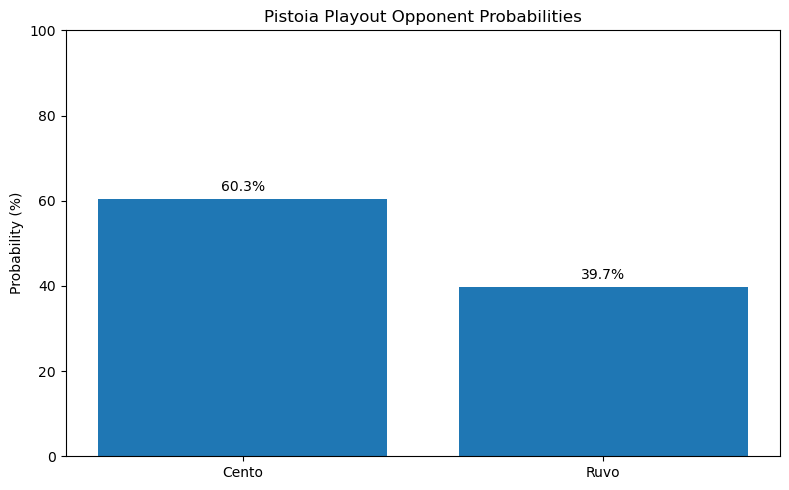

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(summary_df["Pistoia opponent"], summary_df["probability_pct"])
plt.title("Pistoia Playout Opponent Probabilities")
plt.ylabel("Probability (%)")
plt.ylim(0, 100)

for i, v in enumerate(summary_df["probability_pct"]):
    plt.text(i, v + 2, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()


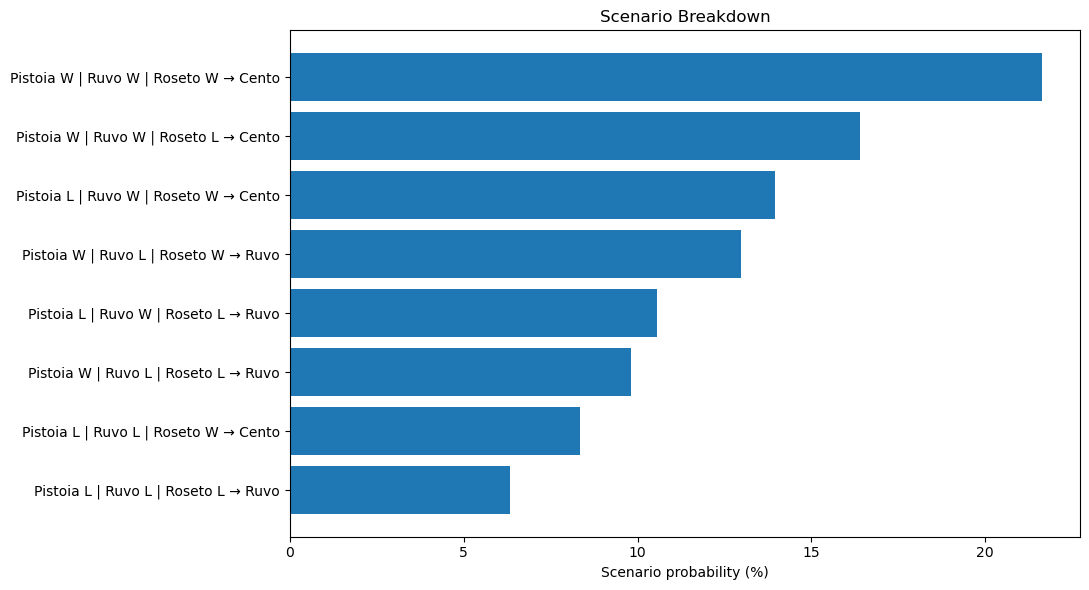

In [11]:
scenario_plot = scenario_df.copy()
scenario_plot["scenario_label"] = (
    "Pistoia " + scenario_plot["Pistoia result at Cento"] +
    " | Ruvo " + scenario_plot["Ruvo result at Brindisi"] +
    " | Roseto " + scenario_plot["Roseto result at Avellino"] +
    " → " + scenario_plot["Pistoia opponent"]
)

plt.figure(figsize=(11, 6))
plt.barh(scenario_plot["scenario_label"], scenario_plot["scenario_probability_pct"])
plt.title("Scenario Breakdown")
plt.xlabel("Scenario probability (%)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Conclusion

This model uses team-level box score data, possession-based ratings and recent form.

The key analytical point is not just the final percentage: Pistoia's opponent is controlled by a combination of their own result and two other final-round games. In particular:

- if Pistoia wins, Ruvo's result becomes decisive;
- if Pistoia loses, Roseto's result becomes decisive.
